# Project 02 — Black-Scholes, Greeks & Derivatives Risk

## Notebook 02 — Black-Scholes Pricing

This notebook implements the Black-Scholes model for European call and put options
and compares theoretical prices with observed market prices.

### Objectives

- Implement the Black-Scholes pricing model.
- Understand the key inputs that drive option value.
- Calculate theoretical call and put prices.
- Compare model prices with observed market prices.
- Examine how option prices vary across strike prices.
- Understand the practical limitations of the Black-Scholes model.

The model provides the theoretical pricing foundation for the subsequent analysis
of Greeks, implied volatility, and derivatives stress testing.

## 1. Black-Scholes Model

The Black-Scholes model provides a theoretical value for European-style options
based on a set of market and contract inputs.

The primary inputs are:

| Input | Symbol | Description |
|---|---:|---|
| Spot price | $S$ | Current price of the underlying |
| Strike price | $K$ | Option exercise price |
| Time to maturity | $T$ | Time remaining until expiration |
| Risk-free rate | $r$ | Continuously compounded risk-free interest rate |
| Dividend yield | $q$ | Continuous dividend yield of the underlying |
| Volatility | $\sigma$ | Annualized volatility of the underlying |

For this project, the Black-Scholes model will be used as a practical pricing
framework rather than explored through its mathematical derivation.

### 1.1 Black-Scholes Equations

The model first calculates:

$$
d_1 = \frac{\ln(S/K) + \left(r - q + \frac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}}
$$

$$
d_2 = d_1 - \sigma\sqrt{T}
$$

The European call price is:

$$
C = S e^{-qT} N(d_1) - K e^{-rT} N(d_2)
$$

The European put price is:

$$
P = K e^{-rT} N(-d_2) - S e^{-qT} N(-d_1)
$$

where $N(\cdot)$ is the cumulative distribution function of the standard normal
distribution.

## 2. Load Market Data

Notebook 01 created the cleaned SPY option-chain dataset.

Notebook 02 uses this saved dataset rather than retrieving the option chain again.
This keeps the pricing analysis reproducible and separates market-data collection
from model implementation.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [ ]:
import sys

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from project_02_derivatives_risk_engine.src.black_scholes import black_scholes_price

: 

In [5]:
data_path = Path("../results/csv/spy_option_chain_clean.csv")

options = pd.read_csv(data_path)

print(f"Loaded {len(options)} option contracts")

options.head()

Loaded 256 option contracts


,contract_symbol,option_type,expiration,spot,strike,days_to_expiry,T,moneyness,bid,ask,mid_price,last_price,volume,open_interest,implied_volatility,intrinsic_value,time_value,in_the_money
0,SPY261120C00620000,call,2026-11-20,774.886292,620.0,44,0.120548,0.800117,156.37,160.18,158.275,158.81,6.0,45,0.485814,154.886292,3.388708,True
1,SPY261120C00625000,call,2026-11-20,774.886292,625.0,44,0.120548,0.806570,151.51,155.25,153.380,154.00,2.0,7,0.474035,149.886292,3.493708,True
2,SPY261120C00630000,call,2026-11-20,774.886292,630.0,44,0.120548,0.813023,147.20,150.37,148.785,145.85,2.0,785,0.463384,144.886292,3.898708,True
3,SPY261120C00635000,call,2026-11-20,774.886292,635.0,44,0.120548,0.819475,142.34,144.60,143.470,134.00,2.0,141,0.431982,139.886292,3.583708,True
4,SPY261120C00640000,call,2026-11-20,774.886292,640.0,44,0.120548,0.825928,137.35,139.56,138.455,138.85,1.0,414,0.418005,134.886292,3.568708,True


## 3. Model Inputs

The Black-Scholes model requires six primary inputs:

- Spot price ($S$)
- Strike price ($K$)
- Time to maturity ($T$)
- Risk-free interest rate ($r$)
- Dividend yield ($q$)
- Volatility ($\sigma$)

The spot price, strike price, and time to maturity are obtained from the
cleaned option-chain dataset.

For this notebook, the risk-free rate, dividend yield, and volatility are
specified as model inputs. Implied volatility will be calculated independently
in a later notebook.

### 3.1 Model Assumptions

For the initial Black-Scholes implementation, the following assumptions are used:

- Risk-free rate: 4.0%
- Dividend yield: 1.2%
- Volatility: 20.0%

These are illustrative model inputs used to demonstrate the pricing framework.
The volatility is treated as an explicit assumption rather than using the
market-provided implied volatility.

Implied volatility will be addressed separately in Notebook 04.

In [8]:
risk_free_rate = 0.04
dividend_yield = 0.012
volatility = 0.20

## 4. Black-Scholes Pricing

The Black-Scholes model can be implemented as a reusable function.

The function will:

1. Calculate $d_1$.
2. Calculate $d_2$.
3. Calculate the theoretical option price.
4. Support both European calls and puts.

### 4.1 Apply the Pricing Model

The pricing function can be applied across the entire option chain to calculate
theoretical Black-Scholes prices for all contracts.

Using the same model assumptions for each contract allows the theoretical prices
to be compared consistently with observed market prices.

In [10]:
options['bs_price'] = options.apply(
    lambda row: black_scholes_price(
        S=row['spot'],
        K=row['strike'],
        T=row['T'],
        r=risk_free_rate,
        q=dividend_yield,
        sigma=volatility,
        option_type=row['option_type']
    ),
    axis=1
)

options[
    [
        "option_type",
        "spot",
        "strike",
        "T",
        "mid_price",
        "bs_price"
    ]
].head(10)

,option_type,spot,strike,T,mid_price,bs_price
0,call,774.886292,620.0,0.120548,158.275,156.755664
1,call,774.886292,625.0,0.120548,153.380,151.783566
2,call,774.886292,630.0,0.120548,148.785,146.813303
3,call,774.886292,635.0,0.120548,143.470,141.845620
4,call,774.886292,640.0,0.120548,138.455,136.881510
5,call,774.886292,645.0,0.120548,133.670,131.922276
6,call,774.886292,650.0,0.120548,128.590,126.969592
7,call,774.886292,655.0,0.120548,123.715,122.025582
8,call,774.886292,660.0,0.120548,119.465,117.092895
9,call,774.886292,665.0,0.120548,113.895,112.174782


## 5. Model vs Market Price

The theoretical Black-Scholes price can now be compared with the observed
market midpoint.

The difference between the two prices provides a simple measure of model
pricing error:

$$
\text{Pricing Error} =
\text{BS Price} - \text{Market Mid Price}
$$

A positive value means the model price is higher than the observed market
price, while a negative value means the model price is lower.

In [11]:
options['pricing_error'] = options['bs_price'] - options['mid_price']
options[
    [
        "option_type",
        "strike",
        "T",
        "mid_price",
        "bs_price",
        "pricing_error"
    ]
]

,option_type,strike,T,mid_price,bs_price,pricing_error
0,call,620.0,0.120548,158.275,156.755664,-1.519336
1,call,625.0,0.120548,153.380,151.783566,-1.596434
2,call,630.0,0.120548,148.785,146.813303,-1.971697
3,call,635.0,0.120548,143.470,141.845620,-1.624380
4,call,640.0,0.120548,138.455,136.881510,-1.573490
...,...,...,...,...,...,...
251,put,840.0,0.120548,65.015,65.923966,0.908966
252,put,850.0,0.120548,75.125,74.791265,-0.333735
253,put,900.0,0.120548,125.020,122.271230,-2.748770
254,put,905.0,0.120548,129.935,127.174565,-2.760435


### 5.1 Pricing Error Summary

A summary of the pricing errors helps assess how closely the Black-Scholes
model matches the observed option prices under the assumed volatility.

In [12]:
options["pricing_error"].describe()

count    256.000000
mean       2.760789
std        3.297373
min       -2.973595
25%       -0.113801
50%        2.277860
75%        6.049707
max        8.171370
Name: pricing_error, dtype: float64

## 6. Pricing Across Strike

Option prices vary with the strike price.

Examining prices across strikes helps illustrate the relationship between
moneyness and option value and provides a simple visual comparison between
Black-Scholes theoretical prices and observed market prices.

### 6.1 Call Price Across Strike

For a fixed expiration, the theoretical call price should generally decrease
as the strike price increases.

We compare the Black-Scholes prices with the observed market midpoint.

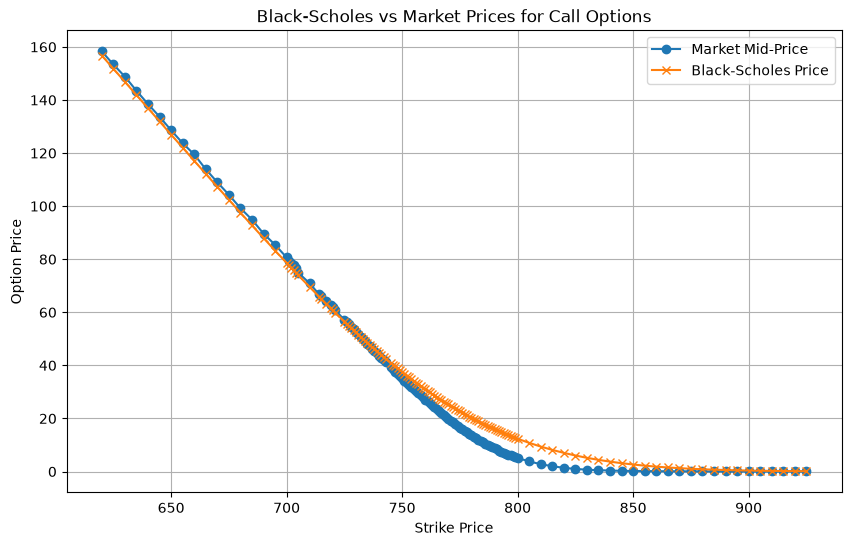

In [16]:
calls = options[options['option_type'] == 'call']

plt.figure(figsize=(10, 6))
plt.plot(
    calls['strike'],
    calls['mid_price'],
    marker = 'o',
    label = 'Market Mid-Price'
)

plt.plot(
    calls['strike'],
    calls['bs_price'],
    marker = 'x',
    label = 'Black-Scholes Price'
)
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.title('Black-Scholes vs Market Prices for Call Options')
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/figures/bs_call_price_vs_strike.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 6.2 Put Price Across Strike

The same comparison can be performed for put options.

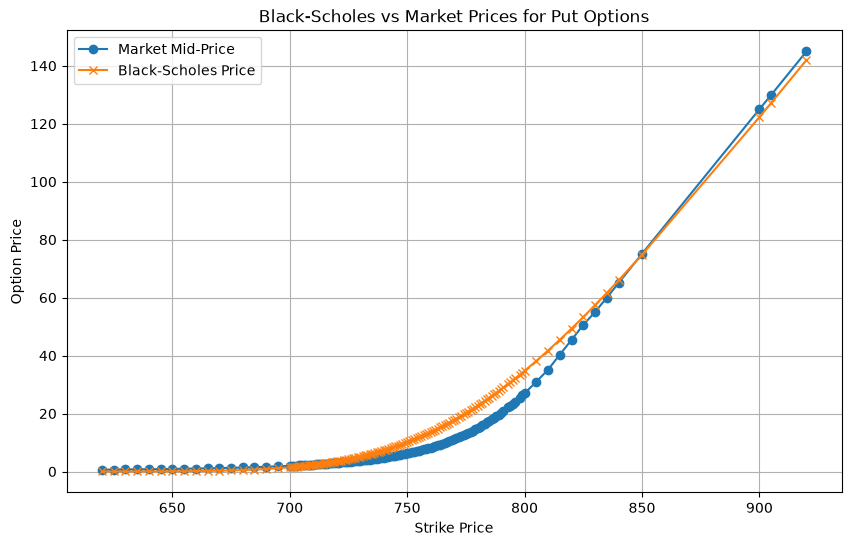

In [17]:
puts = options[options['option_type'] == 'put']

plt.figure(figsize=(10, 6))
plt.plot(
    puts['strike'],
    puts['mid_price'],
    marker = 'o',
    label = 'Market Mid-Price'
)

plt.plot(
    puts['strike'],
    puts['bs_price'],
    marker = 'x',
    label = 'Black-Scholes Price'
)
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.title('Black-Scholes vs Market Prices for Put Options')
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/figures/bs_put_price_vs_strike.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Model Limitations

Black-Scholes provides a useful theoretical framework for European option
pricing, but it relies on simplifying assumptions.

Key limitations include:

- Volatility is assumed to be constant.
- Interest rates are assumed to be constant.
- The model assumes continuous trading.
- Transaction costs and market frictions are ignored.
- The underlying price is assumed to follow a lognormal distribution.
- The model does not capture the volatility smile or skew observed in real
  option markets.
- Black-Scholes is designed for European-style exercise and does not directly
  account for early exercise of American options.

These limitations help explain why theoretical prices based on a single
volatility assumption can differ from observed market prices.

Later notebooks will address some of these differences through implied
volatility, Greeks, and stress testing.